# UHI Modelling V2

I am attempting a revised workflow for modelling UHI.
First, the model is now going to include weather variables obtained from OpenMeteo. The data will then be aggregated with the Landsat data and used to build the model with the workflow below:  
1. Identify the world's climates from an authority (like the Trewartha climate classification).
2. Get substantial satellite (which will eventually include those those climate categories) and weather data on countries in those regions across the months (seasons) in a particular year.
3. Train a model on the data, implementing train-validation-test split, and predict UHI intensity on the test set.
4. Group the test examples by climate and compute the RMSE scores across the climates.
5. Cluster the UHI features to identify the types and categories of UHI.
6. Then I, human, assess the errors and prediction accuracies across each manufactured UHI cluster and how they vary across climates.

***"This project predicts urban heat island intensity using satellite and environmental data and evaluates how prediction reliability and errors vary across global climates and urban thermal types."***

## Testing aggregation with minimal data

To test the flow of data:  
1. From the various countries
2. In the various climates
3. Once a week from Jan 1 2025 to Dec 31 2025
4. From Earth Engine (Landsat) and OpenMeteo

I will be using as minimal data as possible. This will look like:  
1. Lagos, Ontario, Helsinki, and Tehran
2. Aw, Dc, Dcb, Bsk
3. Once a month Jan 1 2025 to Dec 31 2025
4. From Earth Engine and OpenMeteo

## Fetching from Open-Meteo

Again, the cities I want to sample are:
1. Lagos, Nigeria
2. Ontario, Canada
3. Tehran, Iran
4. Helsinki, Finland

The variables I am getting from Open-meteo are:
1. Cloud Cover (Low)
2. Air Temperature (2m)
3. Ralative Humidity
4. Precipitation
5. Wind Speed (10m)

In [1]:
import ee
import geopandas as gpd

ee.Authenticate()
ee.Initialize()

In [3]:
from spectral import get_spectral
from weather import process_city_weather

cities = [
    {"code": "CAN", "name": "Ontario"},
    {"code": "IRN", "name": "Tehran"},
    {"code": "NGA", "name": "Lagos"},
	{"code": "FIN", "name": "Uusimaa"},
]

date_range = ("2025-01-01", "2025-12-31")

for city in cities:
    get_spectral(city['code'], city['name'], date_range)
    # process_city_weather(city['code'], date_range)


Data has already been processed at data/CAN_spectral_features.csv.

Data has already been processed at data/IRN_spectral_features.csv.

Data has already been processed at data/NGA_spectral_features.csv.

Read shapefile...
Creating image from date range within shapefile bounds...
Image created.
Merging all the features...
Features merged.
Sampling 4000 points...
Sampling done.
Adding lat/lon for all the points
Done adding coordinates
Done with EE.
Sampling Urban...
Sampling Rural...
Concatenating and saving...
Done. Saved at "data/FIN_spectral_features.csv"


In [4]:
import pandas as pd

for city in cities:
    df = pd.read_csv(f"data/{city['code']}_spectral_features.csv")
    urban = (df["LandCover"] == 50).sum()
    rural = (df["LandCover"] != 50).sum()
    print(f"{city['name']}: {urban} urban, {rural} rural, total: {len(df)}")

Ontario: 100 urban, 100 rural, total: 200
Tehran: 100 urban, 100 rural, total: 200
Lagos: 100 urban, 100 rural, total: 200
Uusimaa: 100 urban, 100 rural, total: 200


In [ ]:
for city in cities:
    process_city_weather(city['code'], date_range)

Now that we have fetched our data, we will add the `city` column and concatenate all four datasets.

In [3]:
import pandas as pd

can_data = pd.read_csv("data/CAN_Full_UHI_Data.csv")
fin_data = pd.read_csv("data/FIN_Full_UHI_Data.csv")
irn_data = pd.read_csv("data/IRN_Full_UHI_Data.csv")
nga_data = pd.read_csv("data/NGA_Full_UHI_Data.csv")

In [4]:
uhi_data = pd.concat([can_data, fin_data, irn_data, nga_data], keys = ["Ontario", "Uusimaa", "Tehran", "Lagos"])

uhi_data = uhi_data.reset_index(level = 0).rename(columns = {"level_0": "city"})

In [5]:
print(uhi_data.head())
print(uhi_data.info())

      city                       date   humidity  precipitation  wind_speed  \
0  Ontario  2025-01-01 08:00:00+00:00  94.679740            0.3   10.009036   
1  Ontario  2025-01-01 14:00:00+00:00  88.242770            0.0   20.671806   
2  Ontario  2025-01-01 20:00:00+00:00  76.298164            0.1   25.172340   
3  Ontario  2025-02-01 08:00:00+00:00  76.699220            0.0   15.503006   
4  Ontario  2025-02-01 14:00:00+00:00  67.192100            0.0    6.248360   

   cloud_cover_low  air_temperature      Albedo   Elevation         LST  \
0            100.0            -0.25  19140.6732  300.671021  277.975567   
1             52.0            -0.90  19140.6732  300.671021  277.975567   
2            100.0            -0.80  19140.6732  300.671021  277.975567   
3              0.0           -17.75  19140.6732  300.671021  277.975567   
4              0.0           -21.85  19140.6732  300.671021  277.975567   

   LandCover     MNDWI      NDBI      NDVI      SAVI   latitude  longitude

Let's clean up the data:
1. Convert date to datetime
2. Convert city to category
3. Convert LandCover to category

In [6]:
uhi_data["date"] = pd.to_datetime(uhi_data["date"])

uhi_data.loc[uhi_data["date"].dt.hour.isin(range(6, 11)), "time"] = "morning"
uhi_data.loc[uhi_data["date"].dt.hour.isin(range(12, 15)), "time"] = "afternoon"
uhi_data.loc[uhi_data["date"].dt.hour.isin(range(16, 23)), "time"] = "evening"
    
print(uhi_data.head())

      city                      date   humidity  precipitation  wind_speed  \
0  Ontario 2025-01-01 08:00:00+00:00  94.679740            0.3   10.009036   
1  Ontario 2025-01-01 14:00:00+00:00  88.242770            0.0   20.671806   
2  Ontario 2025-01-01 20:00:00+00:00  76.298164            0.1   25.172340   
3  Ontario 2025-02-01 08:00:00+00:00  76.699220            0.0   15.503006   
4  Ontario 2025-02-01 14:00:00+00:00  67.192100            0.0    6.248360   

   cloud_cover_low  air_temperature      Albedo   Elevation         LST  \
0            100.0            -0.25  19140.6732  300.671021  277.975567   
1             52.0            -0.90  19140.6732  300.671021  277.975567   
2            100.0            -0.80  19140.6732  300.671021  277.975567   
3              0.0           -17.75  19140.6732  300.671021  277.975567   
4              0.0           -21.85  19140.6732  300.671021  277.975567   

   LandCover     MNDWI      NDBI      NDVI      SAVI   latitude  longitude  \
0 

Apparently, our Albedo values are unusbale. We didn't apply the scaling necessary to make the values go from 0 to 1.

In [7]:
# unique_pixels = uhi_data[["latitude", "longitude", "date", "city"]].drop_duplicates().reset_index(drop=True)
# unique_pixels["date_only"] = unique_pixels["date"].dt.date
# unique_pixels.to_csv("data/unique_pixels.csv", index=False)

In [ ]:
# import ee
# import geemap
# import pandas as pd

# ee.Initialize()

# pixels = pd.read_csv("data/unique_pixels.csv")  # must include city column

# results_by_date = []

# for city, group in pixels.groupby("city"):
#     features = [
#         ee.Feature(
#             ee.Geometry.Point([row["longitude"], row["latitude"]]),
#             {"latitude": row["latitude"], "longitude": row["longitude"]}
#         )
#         for _, row in group.iterrows()
#     ]
#     fc = ee.FeatureCollection(features)
    
#     image = (
#         ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
#         .filterBounds(fc)
#         .filterDate("2025-01-01", "2025-12-31")
#         .median()
#         .select(["SR_B2", "SR_B4", "SR_B5", "SR_B6", "SR_B7"])
#         .multiply(0.0000275).add(-0.2)
#     )
    
#     albedo = image.expression(
#         "0.356*B2 + 0.130*B4 + 0.373*B5 + 0.085*B6 + 0.072*B7 - 0.0018",
#         {
#             "B2": image.select("SR_B2"),
#             "B4": image.select("SR_B4"),
#             "B5": image.select("SR_B5"),
#             "B6": image.select("SR_B6"),
#             "B7": image.select("SR_B7"),
#         }
#     ).rename("Albedo")
    
#     sampled = albedo.sampleRegions(
#         collection=fc,
#         properties=["latitude", "longitude"],
#         scale=30
#     )
    
#     results_by_date.append(sampled)

# all_results = ee.FeatureCollection(results_by_date).flatten()
# geemap.ee_to_csv(all_results, filename="data/albedo_corrected.csv")

Now that we have the corrected albedo values, let's join to the master dataframe.

In [9]:
uhi_data = uhi_data.drop(columns=["Albedo"])  # if not already dropped

albedo_corrected = pd.read_csv("data/albedo_corrected.csv")
albedo_corrected = albedo_corrected[["latitude", "longitude", "Albedo"]].drop_duplicates(subset=["latitude", "longitude"])

uhi_data = uhi_data.merge(
    albedo_corrected,
    on=["latitude", "longitude"],
    how="left"
)

print(len(uhi_data))

28764


In [10]:
print(albedo_corrected[["latitude", "longitude"]].duplicated().sum())
print(len(albedo_corrected))

0
799


In [11]:
print(uhi_data["Albedo"].isnull().sum())
print(uhi_data["Albedo"].describe())

0
count    28764.000000
mean         0.197476
std          0.081107
min          0.004102
25%          0.141530
50%          0.189004
75%          0.238129
max          0.579815
Name: Albedo, dtype: float64


I am going to experiment with clustering the points to identify the inherent climate classifications they belong to, because I cannot find a fine-grained Trewartha classification.

In [12]:
pixel_profiles = uhi_data.groupby(["latitude", "longitude"]).agg(
    mean_temp=("air_temperature", "mean"),
    mean_humidity=("humidity", "mean"),
    total_precip=("precipitation", "sum"),
    mean_wind=("wind_speed", "mean"),
    mean_cloud=("cloud_cover_low", "mean")
).reset_index()

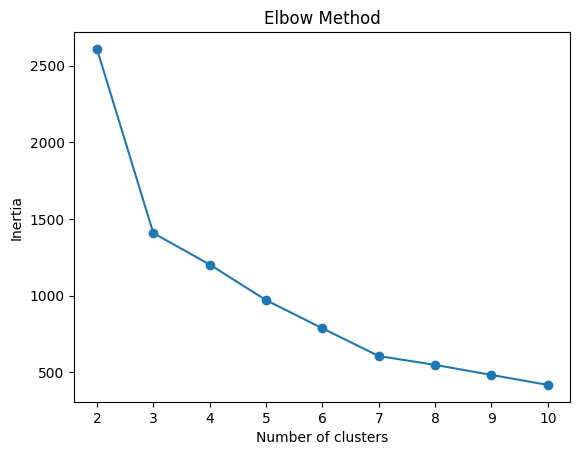

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = ["mean_temp", "mean_humidity", "total_precip", "mean_wind", "mean_cloud"]

scaler = StandardScaler()
scaled = scaler.fit_transform(pixel_profiles[features])

# Elbow method to find optimal k
inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled)
    inertias.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [14]:
print(inertias)

[2608.344575759464, 1408.6595397574945, 1203.1858188165954, 971.5857409291859, 787.8788250547356, 607.0321460178801, 549.6010860214396, 484.0909081930291, 419.0119527136093]


In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = ["mean_temp", "mean_humidity", "total_precip", "mean_wind", "mean_cloud"]

scaler = StandardScaler()
scaled = scaler.fit_transform(pixel_profiles[features])

for k in [4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    pixel_profiles[f"cluster_k{k}"] = km.fit_predict(scaled)

# Compare cluster compositions — mean profile per cluster
for k in [4, 5]:
    print(f"\n--- k={k} ---")
    print(pixel_profiles.groupby(f"cluster_k{k}")[features].mean().round(2))
    print("\nCity distribution per cluster:")
    merged = pixel_profiles.merge(uhi_data[["latitude", "longitude", "city"]].drop_duplicates(), on=["latitude", "longitude"])
    print(merged.groupby([f"cluster_k{k}", "city"]).size().unstack(fill_value=0))


--- k=4 ---
            mean_temp  mean_humidity  total_precip  mean_wind  mean_cloud
cluster_k4                                                               
0               15.69          36.19          0.41       9.49        4.51
1                8.01          77.97          2.07      11.44       51.90
2               27.51          80.75          3.83      10.50       17.34
3                1.66          69.69          0.93      12.46       34.21

City distribution per cluster:
city        Lagos  Ontario  Tehran  Uusimaa
cluster_k4                                 
0               0        0     198        0
1               0       13       0      199
2             200        0       0        0
3               0      186       2        1

--- k=5 ---
            mean_temp  mean_humidity  total_precip  mean_wind  mean_cloud
cluster_k5                                                               
0               15.69          36.19          0.41       9.49        4.51
1           

Now, joining the clusters to the original dataframe:

In [16]:
uhi_data = uhi_data.merge(
    pixel_profiles[["latitude", "longitude", "cluster_k4"]].rename(columns={"cluster_k4": "climate"}),
    on=["latitude", "longitude"],
    how="left"
)

print(uhi_data["climate"].value_counts())
print(uhi_data["climate"].isnull().sum())

climate
1    7632
2    7200
0    7128
3    6804
Name: count, dtype: int64
0


In [17]:
uhi_data["is_urban"] = (uhi_data["LandCover"] == 50).astype(int)

# Separate urban and rural
urban = uhi_data[uhi_data["is_urban"] == 1].groupby(["city", "date", "time"]).agg(
    LST_urban=("LST", "mean"),
    airtemp_urban=("air_temperature", "mean"),
    n_urban=("LST", "count")
).reset_index()

rural = uhi_data[uhi_data["is_urban"] == 0].groupby(["city", "date", "time"]).agg(
    LST_rural=("LST", "mean"),
    airtemp_rural=("air_temperature", "mean"),
    n_rural=("LST", "count")
).reset_index()

# Merge and compute UHI intensity
uhi_intensity = urban.merge(rural, on=["city", "date", "time"], how="inner")
uhi_intensity["SUHI"] = uhi_intensity["LST_urban"] - uhi_intensity["LST_rural"]
uhi_intensity["AUHI"] = uhi_intensity["airtemp_urban"] - uhi_intensity["airtemp_rural"]

print(uhi_intensity.shape)
print(uhi_intensity[["SUHI", "AUHI"]].describe())
print(uhi_intensity["n_urban"].value_counts())
print(uhi_intensity["n_rural"].value_counts())

(144, 11)
             SUHI        AUHI
count  144.000000  144.000000
mean     1.626256    2.889692
std      2.298633    3.709076
min     -1.391963   -4.379207
25%      0.385629    0.059583
50%      1.449252    0.686631
75%      2.689879    5.780725
max      4.998483   15.068773
n_urban
45    36
1     36
11    36
12    36
Name: count, dtype: int64
n_rural
155    36
198    36
189    36
188    36
Name: count, dtype: int64


In [18]:
uhi_data[uhi_data["is_urban"] == 1].groupby("city").size()

city
Lagos      1620
Ontario      36
Tehran      396
Uusimaa     432
dtype: int64